## comparing fine-tuning and zero-shot evaluation
instead of just asking "how fair are pretrained models over time?", we are also interested in:
- how does task adaption change accuracy and fairness?
- do models move in similar direction after fine-tuning?
- does fine-tuning reduce group disparities, increase them, or trade fairness against accuracy?

will do:
- zero-shot
- fine-tuning (parameter-efficient fine-tuning, LoRA)
will start with:
- a older and smaller model: EleutherAI/gpt-neo-2.7B
- a mid-generation model: mistralai/Mistral-7B-v0.1
- a newer and stronger model: Qwen/Qwen2.5-7B
base models, from different time points, widely used 
<br>
<br>
will be using the CivilComments WILDS dataset, which already have labeled training, validation, and test data

In [1]:
# imports
import os
import gc
import re
import json
import math
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from datasets import Dataset
from wilds import get_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)
from peft import (
    LoraConfig,
    PeftModel,
    prepare_model_for_kbit_training,
)
from trl import SFTTrainer, SFTConfig

In [2]:
gc.collect()
torch.cuda.empty_cache()

In [3]:
# config
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True

os.environ["TOKENIZERS_PARALLELISM"] = "false"

N_EVAL = 2000
CAL_FRAC = 0.5

# training subset sizes
# starting smaller so it doesnt take 7+ hours
FT_TRAIN_MAX = 8000
FT_VAL_MAX = 1000

# prompt + labels
PROMPT_TMPL = "Text:\n{txt}\nQuestion: Should this text be flagged for toxicity?\nAnswer:"
LABEL_POS = " yes"
LABEL_NEG = " no"

# sequence length
MAX_LEN_EVAL = 128
MAX_LEN_TRAIN = 128 # prompt and labels are short so should be ok + save time

# LoRA / QLoRA-style setup
COMPUTE_DTYPE = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16

BNB_CONFIG = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
)

# output
OUT_DIR = "results_civilcomments_zeroshot_vs_ft"
os.makedirs(OUT_DIR, exist_ok=True)

IDX_PATH = "eval_idx.npy"
CAL_PATH = "cal_idx.npy"
TEST_PATH = "test_idx.npy"

SUMMARY_CSV = os.path.join(OUT_DIR, "before_after_summary.csv")
GROUPS_CSV = os.path.join(OUT_DIR, "before_after_groups.csv")

MODEL_SPECS = [
    {
        "year": 2021,
        "id": "EleutherAI/gpt-neo-2.7B",
        "short_name": "gpt-neo-2.7B",
        "trust_remote_code": False,
        "eval_batch_size": 8,
        "train_batch_size": 4,
        "grad_accum": 8,
        "lr": 2e-4,
        "epochs": 1.0,
    },
    {
        "year": 2023,
        "id": "mistralai/Mistral-7B-v0.1",
        "short_name": "Mistral-7B",
        "trust_remote_code": False,
        "eval_batch_size": 4,
        "train_batch_size": 4,
        "grad_accum": 8,
        "lr": 2e-4,
        "epochs": 1.0,
    },
    {
        "year": 2024,
        "id": "Qwen/Qwen2.5-7B",
        "short_name": "Qwen2.5-7B",
        "trust_remote_code": False,
        "eval_batch_size": 4,
        "train_batch_size": 4,
        "grad_accum": 8,
        "lr": 2e-4,
        "epochs": 1.0,
    },
    {
        "year": 2022,
        "id": "facebook/opt-6.7b",
        "short_name": "OPT-6.7b",
        "trust_remote_code": False,
        "eval_batch_size": 4,
        "train_batch_size": 4,
        "grad_accum": 8,
        "lr": 2e-4,
        "epochs": 1.0,
    },
    {
        "year": 2023,
        "id": "meta-llama/Llama-2-7b-hf",
        "short_name": "Llama-2-7b",
        "trust_remote_code": False,
        "eval_batch_size": 4,
        "train_batch_size": 4,
        "grad_accum": 8,
        "lr": 2e-4,
        "epochs": 1.0,
    },
    {
        "year": 2023,
        "id": "openlm-research/open_llama_7b",
        "short_name": "openLLaMa_7b",
        "trust_remote_code": False,
        "eval_batch_size": 4,
        "train_batch_size": 4,
        "grad_accum": 8,
        "lr": 2e-4,
        "epochs": 1.0,
    },

]

In [4]:
# helpers
def slugify_model_id(model_id: str) -> str:
    s = model_id.strip().replace("/", "__")
    s = re.sub(r"[^A-Za-z0-9_\-\.]+", "_", s)
    return s[:180]


def cleanup(*objs):
    for obj in objs:
        try:
            del obj
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def summarize_across_groups(values_by_group: dict, eps=1e-12):
    vals = np.array([v for v in values_by_group.values() if not np.isnan(v)], dtype=float)
    if len(vals) == 0:
        return {"minmax_abs": np.nan, "minmax_rel": np.nan, "var": np.nan}
    mm = float(vals.max() - vals.min())
    rel = float(mm / (vals.mean() + eps))
    var = float(vals.var())
    return {"minmax_abs": mm, "minmax_rel": rel, "var": var}


def confusion_rates(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    pos_rate = y_pred.mean() if len(y_pred) else np.nan
    acc = (y_true == y_pred).mean() if len(y_pred) else np.nan

    return {
        "acc": acc,
        "pos_rate": pos_rate,
        "fpr": fpr,
        "fnr": fnr,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
    }

In [5]:
# load WILDS CivilComments
dataset = get_dataset(dataset="civilcomments", download=True)

train_data = dataset.get_subset("train", transform=None)
val_data = dataset.get_subset("val", transform=None)
test_data = dataset.get_subset("test", transform=None)

print("metadata_fields:", dataset.metadata_fields)
print("train/val/test sizes:", len(train_data), len(val_data), len(test_data))

identity_names = ["male", "female", "LGBTQ", "christian", "muslim", "other_religions", "black", "white"]
field_lc = [f.lower() for f in dataset.metadata_fields]
identity_cols = {}
for name in identity_names:
    hits = [j for j, f in enumerate(field_lc) if name.lower() in f]
    identity_cols[name] = hits[0] if hits else None

identity_cols

metadata_fields: ['male', 'female', 'LGBTQ', 'christian', 'muslim', 'other_religions', 'black', 'white', 'identity_any', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack', 'sexual_explicit', 'y', 'from_source_domain']
train/val/test sizes: 269038 45180 133782


{'male': 0,
 'female': 1,
 'LGBTQ': 2,
 'christian': 3,
 'muslim': 4,
 'other_religions': 5,
 'black': 6,
 'white': 7}

In [6]:
# fixed evaluation subset on test
n_total = len(test_data)

if os.path.exists(IDX_PATH):
    eval_idx = np.load(IDX_PATH)
else:
    rng = np.random.default_rng(SEED)
    eval_idx = rng.choice(n_total, size=min(N_EVAL, n_total), replace=False)
    np.save(IDX_PATH, eval_idx)

if os.path.exists(CAL_PATH) and os.path.exists(TEST_PATH):
    cal_subidx = np.load(CAL_PATH)
    test_subidx = np.load(TEST_PATH)
else:
    rng = np.random.default_rng(SEED)
    perm = rng.permutation(len(eval_idx))
    cut = int(len(eval_idx) * CAL_FRAC)
    cal_subidx = perm[:cut]
    test_subidx = perm[cut:]
    np.save(CAL_PATH, cal_subidx)
    np.save(TEST_PATH, test_subidx)

texts_eval, y_true_eval, metadata_eval = [], [], []
for i in eval_idx:
    x, y, m = test_data[int(i)]
    texts_eval.append(x)
    y_true_eval.append(int(y))
    metadata_eval.append(m.numpy() if hasattr(m, "numpy") else np.array(m))

y_true_eval = np.array(y_true_eval, dtype=int)
metadata_eval = np.stack(metadata_eval, axis=0)

print("Eval N:", len(eval_idx), "CAL N:", len(cal_subidx), "TEST N:", len(test_subidx))

Eval N: 2000 CAL N: 1000 TEST N: 1000


In [7]:
# make SFT train/val datasets
# prompt-completion format
def subset_to_prompt_completion(split_data, max_n=None, seed=42):
    n = len(split_data)
    idx = np.arange(n)

    if (max_n is not None) and (max_n < n):
        rng = np.random.default_rng(seed)
        idx = rng.choice(n, size=max_n, replace=False)

    rows = []
    for i in idx:
        x, y, _ = split_data[int(i)]
        prompt = PROMPT_TMPL.format(txt=(x if x is not None else ""))
        completion = LABEL_POS if int(y) == 1 else LABEL_NEG
        rows.append({"prompt": prompt, "completion": completion})

    return Dataset.from_list(rows)

train_ds = subset_to_prompt_completion(train_data, max_n=FT_TRAIN_MAX, seed=SEED)
val_ds = subset_to_prompt_completion(val_data, max_n=FT_VAL_MAX, seed=SEED)

print(train_ds)
print(val_ds)
print(train_ds[2])

Dataset({
    features: ['prompt', 'completion'],
    num_rows: 8000
})
Dataset({
    features: ['prompt', 'completion'],
    num_rows: 1000
})
{'prompt': "Text:\nfunny, I don't own a hoodie, or Nikes or an iPhone. All I have is paid for, education included. I do believe in single payer healthcare and society's responsibility to take care of the least fortunate at the expense of the most fortunate. Bread and Medicine for everyone, bread and medicine before offensive weapons, bread and medicine before political gain, bread and medicine before individual wealth. Egalitarianism over capitalism. With these words, you would know me socialist, and me sitting next to you so close we could see the common blood that rages in our veins. Our eyes so similar that even hate or compassion is reflected. This is how civil wars start or how peace is found. This division can not multiply without eventual resolution. Our anonymous ink in occult fashion blots the sun. Wicked, wicked men, we will be undone

In [8]:
# zero-shot scoring
# cache-free fallback for multi-token labels
@torch.inference_mode()
def logp_label_given_prompt(tokenizer, model, prompts, label_str, max_len):
    tok_prompt = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=max_len,
    )
    dev = model.get_input_embeddings().weight.device
    tok_prompt = {k: v.to(dev) for k, v in tok_prompt.items()}

    full_texts = [p + label_str for p in prompts]
    tok_full = tokenizer(
        full_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=max_len,
    )
    tok_full = {k: v.to(dev) for k, v in tok_full.items()}

    out = model(**tok_full, use_cache=False)
    logits = out.logits

    input_ids = tok_full["input_ids"]
    attn = tok_full["attention_mask"]

    shift_logits = logits[:, :-1, :]
    shift_labels = input_ids[:, 1:]
    logprobs = F.log_softmax(shift_logits, dim=-1)
    token_logp = logprobs.gather(-1, shift_labels.unsqueeze(-1)).squeeze(-1)

    prompt_lens = tok_prompt["attention_mask"].sum(dim=1)
    full_lens = attn.sum(dim=1)

    total_logp = torch.zeros(input_ids.shape[0], device=dev)

    for b in range(input_ids.shape[0]):
        start = int(prompt_lens[b].item()) - 1
        end = int(full_lens[b].item()) - 1
        if end > start:
            total_logp[b] = token_logp[b, start:end].sum()

    return total_logp


@torch.inference_mode()
def predict_toxic_proba(tokenizer, model, texts, max_len):
    prompts = [PROMPT_TMPL.format(txt=(t if t is not None else "")) for t in texts]

    yes_ids = tokenizer(LABEL_POS, add_special_tokens=False).input_ids
    no_ids = tokenizer(LABEL_NEG, add_special_tokens=False).input_ids

    # fast path: both labels single-token
    if len(yes_ids) == 1 and len(no_ids) == 1:
        YES_ID, NO_ID = yes_ids[0], no_ids[0]

        tok = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_len,
        )
        dev = model.get_input_embeddings().weight.device
        tok = {k: v.to(dev) for k, v in tok.items()}

        out = model(**tok, use_cache=False)
        next_logits = out.logits[:, -1, :]
        logits2 = next_logits[:, [NO_ID, YES_ID]].to(torch.float32)
        probs_yes = torch.softmax(logits2, dim=-1)[:, 1]
        return probs_yes.float().cpu().numpy()

    # fallback: compute full continuation likelihood
    lp_pos = logp_label_given_prompt(tokenizer, model, prompts, LABEL_POS, max_len)
    lp_neg = logp_label_given_prompt(tokenizer, model, prompts, LABEL_NEG, max_len)
    stacked = torch.stack([lp_neg, lp_pos], dim=-1)
    probs_pos = torch.softmax(stacked, dim=-1)[:, 1]
    return probs_pos.float().cpu().numpy()


def infer_with_progress(tokenizer, model, texts, batch_size, max_len, label=""):
    N = len(texts)
    p = np.zeros(N, dtype=float)

    total_batches = (N + batch_size - 1) // batch_size
    step = max(1, total_batches // 10)

    t0 = time.perf_counter()
    for b, s in enumerate(range(0, N, batch_size), start=1):
        batch_texts = texts[s : s + batch_size]
        p[s : s + batch_size] = predict_toxic_proba(tokenizer, model, batch_texts, max_len=max_len)

        if b % step == 0 or b == total_batches:
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            elapsed = time.perf_counter() - t0
            frac = b / total_batches
            eta = elapsed * (1 / frac - 1) if frac > 0 else float("inf")
            print(f"{label}{frac*100:5.1f}%  batches {b}/{total_batches}  elapsed {elapsed:6.1f}s  ETA {eta:6.1f}s")

    return p

In [9]:
# load model for eval or FT
def load_tokenizer(model_id, trust_remote_code=False):
    tok = AutoTokenizer.from_pretrained(model_id, use_fast=True, trust_remote_code=trust_remote_code)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    tok.padding_side = "left"
    return tok


def load_base_model_quantized_eval(model_id, trust_remote_code=False, use_cache=False):
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=BNB_CONFIG,
        device_map="auto",
        torch_dtype=COMPUTE_DTYPE,
        trust_remote_code=trust_remote_code,
    )
    model.config.use_cache = use_cache
    model.eval()
    return model

def load_base_model_quantized_train(model_id, trust_remote_code=False, use_cache=False):
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=BNB_CONFIG,
        device_map={"": 0},
        torch_dtype=COMPUTE_DTYPE,
        trust_remote_code=trust_remote_code,
    )
    model.config.use_cache = use_cache
    return model

In [10]:
# LoRA target module helper
def infer_lora_target_modules(model):
    linear_leaf_names = sorted({
        name.split(".")[-1]
        for name, module in model.named_modules()
        if isinstance(module, torch.nn.Linear)
    })

    candidates = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "out_proj", "query_key_value", "c_attn"
    ]
    targets = [m for m in candidates if m in linear_leaf_names]

    if len(targets) == 0:
        raise ValueError(f"Could not infer LoRA target modules. Found linear leaves: {linear_leaf_names[:50]}")

    return targets

In [11]:
# evaluation on fixed test subset
# same fairness pipeline as zero-shot notebook
def evaluate_model_on_fixed_subset(model_id, tokenizer, model, year, eval_batch_size):
    p_toxic = infer_with_progress(
        tokenizer, model, texts_eval,
        batch_size=eval_batch_size,
        max_len=MAX_LEN_EVAL,
        label=f"[{year}] "
    )

    base_rate_cal = float(y_true_eval[cal_subidx].mean())
    thr = float(np.quantile(p_toxic[cal_subidx], 1 - base_rate_cal))
    y_pred = (p_toxic >= thr).astype(int)

    y_true_test = y_true_eval[test_subidx]
    y_pred_test = y_pred[test_subidx]
    overall = confusion_rates(y_true_test, y_pred_test)

    group_stats = {}
    for g, col in identity_cols.items():
        if col is None:
            group_stats[g] = {"acc": np.nan, "pos_rate": np.nan, "fpr": np.nan, "fnr": np.nan}
            continue

        mask_all = (metadata_eval[:, col].astype(int) == 1)
        mask_test = mask_all[test_subidx]
        stats = confusion_rates(y_true_test[mask_test], y_pred_test[mask_test])
        group_stats[g] = stats

    fairness = {}
    for metric in ["acc", "pos_rate", "fpr", "fnr"]:
        vals = {g: group_stats[g][metric] for g in group_stats}
        fairness[metric] = summarize_across_groups(vals)

    summary = {
        "year": int(year),
        "model_id": str(model_id),
        "base_rate_cal": base_rate_cal,
        "threshold_t": thr,
        "test_acc": float(overall["acc"]),
        "test_pos_rate": float(overall["pos_rate"]),
        "test_fpr": float(overall["fpr"]),
        "test_fnr": float(overall["fnr"]),
    }

    for metric in ["acc", "pos_rate", "fpr", "fnr"]:
        summary[f"{metric}_minmax_abs"] = float(fairness[metric]["minmax_abs"])
        summary[f"{metric}_minmax_rel"] = float(fairness[metric]["minmax_rel"])
        summary[f"{metric}_var"] = float(fairness[metric]["var"])

    summary["avg_minmax_abs"] = float(np.nanmean([
        summary["acc_minmax_abs"], summary["pos_rate_minmax_abs"],
        summary["fpr_minmax_abs"], summary["fnr_minmax_abs"]
    ]))

    summary["avg_minmax_rel"] = float(np.nanmean([
        summary["acc_minmax_rel"], summary["pos_rate_minmax_rel"],
        summary["fpr_minmax_rel"], summary["fnr_minmax_rel"]
    ]))

    summary["avg_var"] = float(np.nanmean([
        summary["acc_var"], summary["pos_rate_var"],
        summary["fpr_var"], summary["fnr_var"]
    ]))

    rows_g = []
    for g in identity_names:
        s = group_stats[g]
        rows_g.append({
            "year": int(year),
            "model_id": str(model_id),
            "group": g,
            "acc": float(s["acc"]),
            "pos_rate": float(s["pos_rate"]),
            "fpr": float(s["fpr"]),
            "fnr": float(s["fnr"]),
        })

    return summary, pd.DataFrame(rows_g)

In [12]:
# supervised FT with LoRA/QLoRA
def finetune_one_model(spec):
    model_id = spec["id"]
    year = spec["year"]
    short_name = spec["short_name"]
    trust_remote_code = spec.get("trust_remote_code", False)

    adapter_dir = os.path.join(OUT_DIR, f"adapter_{year}__{slugify_model_id(model_id)}")
    os.makedirs(adapter_dir, exist_ok=True)

    print("=" * 90)
    print(f"FINE-TUNE: {model_id}")
    print("=" * 90)

    tokenizer = load_tokenizer(model_id, trust_remote_code=trust_remote_code)

    model = load_base_model_quantized_train(model_id, trust_remote_code=trust_remote_code, use_cache=False)
    # model.gradient_checkpointing_enable()
    model = prepare_model_for_kbit_training(model)

    target_modules = infer_lora_target_modules(model)
    print("LoRA target modules:", target_modules)

    peft_config = LoraConfig(
        r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules=target_modules,
    )

    args = SFTConfig(
        output_dir=adapter_dir,
        per_device_train_batch_size=spec["train_batch_size"],
        per_device_eval_batch_size=1,
        gradient_accumulation_steps=spec["grad_accum"],
        learning_rate=spec["lr"],
        num_train_epochs=spec["epochs"],
        eval_strategy="no", # since we already do full evaluation before and after training, we do not need it duing training + we wont to optimize time spend training
        save_strategy="no",
        logging_steps=20,
        report_to="none",
        max_length=MAX_LEN_TRAIN,
        completion_only_loss=True,
        bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
        fp16=torch.cuda.is_available() and not torch.cuda.is_bf16_supported(),
        gradient_checkpointing=False,
        use_cache=False,
        seed=SEED,
    )

    trainer = SFTTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        processing_class=tokenizer,
        peft_config=peft_config,
    )

    trainer.train()
    trainer.model.save_pretrained(adapter_dir)
    tokenizer.save_pretrained(adapter_dir)

    cleanup(model, trainer, tokenizer)
    return adapter_dir

In [13]:
# evaluate before and after
def evaluate_before_and_after(spec):
    model_id = spec["id"]
    year = spec["year"]
    short_name = spec["short_name"]
    trust_remote_code = spec.get("trust_remote_code", False)
    eval_batch_size = spec["eval_batch_size"]

    print("\n" + "#" * 90)
    print(f"MODEL: {model_id}")
    print("#" * 90)

    tok_dbg = load_tokenizer(model_id, trust_remote_code=trust_remote_code)
    print("yes ids:", tok_dbg(LABEL_POS, add_special_tokens=False).input_ids)
    print("no ids:", tok_dbg(LABEL_NEG, add_special_tokens=False).input_ids)
    cleanup(tok_dbg)

    # 1) zero-shot / base
    tok_base = load_tokenizer(model_id, trust_remote_code=trust_remote_code)
    model_base = load_base_model_quantized_eval(model_id, trust_remote_code=trust_remote_code, use_cache=False)
    print("device map:", getattr(model_base, "hf_device_map", None))

    base_summary, base_groups = evaluate_model_on_fixed_subset(
        model_id=model_id,
        tokenizer=tok_base,
        model=model_base,
        year=year,
        eval_batch_size=eval_batch_size,
    )

    cleanup(model_base, tok_base)

    # 2) FT
    adapter_dir = finetune_one_model(spec)

    tok_ft = load_tokenizer(model_id, trust_remote_code=trust_remote_code)
    model_ft = load_base_model_quantized_train(model_id, trust_remote_code=trust_remote_code, use_cache=False)
    model_ft = PeftModel.from_pretrained(model_ft, adapter_dir)
    model_ft.eval()

    ft_summary, ft_groups = evaluate_model_on_fixed_subset(
        model_id=model_id,
        tokenizer=tok_ft,
        model=model_ft,
        year=year,
        eval_batch_size=eval_batch_size,
    )

    cleanup(model_ft, tok_ft)

    out = {
        "year": year,
        "model_id": model_id,
        "short_name": short_name,
        "adapter_dir": adapter_dir,
        "zero_shot_test_acc": base_summary["test_acc"],
        "zero_shot_avg_minmax_abs": base_summary["avg_minmax_abs"],
        "zero_shot_test_fpr": base_summary["test_fpr"],
        "zero_shot_test_fnr": base_summary["test_fnr"],
        "ft_test_acc": ft_summary["test_acc"],
        "ft_avg_minmax_abs": ft_summary["avg_minmax_abs"],
        "ft_test_fpr": ft_summary["test_fpr"],
        "ft_test_fnr": ft_summary["test_fnr"],
    }

    out["delta_acc"] = out["ft_test_acc"] - out["zero_shot_test_acc"]
    out["delta_fairness"] = out["ft_avg_minmax_abs"] - out["zero_shot_avg_minmax_abs"]

    base_groups = base_groups.copy()
    base_groups["stage"] = "zero_shot"
    ft_groups = ft_groups.copy()
    ft_groups["stage"] = "fine_tuned"
    groups_out = pd.concat([base_groups, ft_groups], ignore_index=True)

    return out, groups_out

In [14]:
# run models
# all_rows = []
# all_groups = []

# for spec in MODEL_SPECS:
#     row, groups_df = evaluate_before_and_after(spec)
#     all_rows.append(row)
#     all_groups.append(groups_df)

# df_summary = pd.DataFrame(all_rows).sort_values(["year", "model_id"]).reset_index(drop=True)
# df_groups = pd.concat(all_groups, ignore_index=True)

# df_summary.to_csv(SUMMARY_CSV, index=False)
# df_groups.to_csv(GROUPS_CSV, index=False)

# df_summary

# skip already completed models
key_cols = ["year", "model_id"]

if os.path.exists(SUMMARY_CSV):
    df_summary_existing = pd.read_csv(SUMMARY_CSV)
    done = set(
        zip(
            df_summary_existing["year"].astype(int),
            df_summary_existing["model_id"].astype(str),
        )
    )
    all_rows = df_summary_existing.to_dict("records")
else:
    done = set()
    all_rows = []

if os.path.exists(GROUPS_CSV):
    df_groups_existing = pd.read_csv(GROUPS_CSV)
    all_groups = [df_groups_existing]
else:
    all_groups = []

for spec in MODEL_SPECS:
    key = (int(spec["year"]), str(spec["id"]))

    if key in done:
        print(f"Skipping already completed model: {spec['id']}")
        continue

    row, groups_df = evaluate_before_and_after(spec)
    all_rows.append(row)
    all_groups.append(groups_df)

    # save progress immediately after each model
    df_summary = pd.DataFrame(all_rows).sort_values(key_cols).reset_index(drop=True)
    df_groups = pd.concat(all_groups, ignore_index=True)

    df_summary.to_csv(SUMMARY_CSV, index=False)
    df_groups.to_csv(GROUPS_CSV, index=False)

df_summary = pd.DataFrame(all_rows).sort_values(key_cols).reset_index(drop=True)
df_groups = pd.concat(all_groups, ignore_index=True)

df_summary

Skipping already completed model: EleutherAI/gpt-neo-2.7B
Skipping already completed model: mistralai/Mistral-7B-v0.1
Skipping already completed model: Qwen/Qwen2.5-7B

##########################################################################################
MODEL: facebook/opt-6.7b
##########################################################################################
yes ids: [4420]
no ids: [117]


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

device map: None
[2022]  10.0%  batches 50/500  elapsed   13.2s  ETA  118.7s
[2022]  20.0%  batches 100/500  elapsed   25.6s  ETA  102.2s
[2022]  30.0%  batches 150/500  elapsed   38.5s  ETA   89.7s
[2022]  40.0%  batches 200/500  elapsed   51.3s  ETA   76.9s
[2022]  50.0%  batches 250/500  elapsed   63.8s  ETA   63.8s
[2022]  60.0%  batches 300/500  elapsed   76.1s  ETA   50.7s
[2022]  70.0%  batches 350/500  elapsed   88.1s  ETA   37.8s
[2022]  80.0%  batches 400/500  elapsed  100.1s  ETA   25.0s
[2022]  90.0%  batches 450/500  elapsed  112.0s  ETA   12.4s
[2022] 100.0%  batches 500/500  elapsed  124.4s  ETA    0.0s
FINE-TUNE: facebook/opt-6.7b


Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

...

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.
c:\Users\vikto\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\torch\_dynamo\eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
20,0.690340
40,0.163130
60,0.141053
80,0.147754
100,0.168472
120,0.149003
140,0.148687
160,0.149070
180,0.153179
200,0.101092


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[2023]  10.0%  batches 50/500  elapsed  674.5s  ETA 6070.5s
[2023]  20.0%  batches 100/500  elapsed 1384.0s  ETA 5536.1s
[2023]  30.0%  batches 150/500  elapsed 2102.5s  ETA 4905.8s
[2023]  40.0%  batches 200/500  elapsed 2801.5s  ETA 4202.2s
[2023]  50.0%  batches 250/500  elapsed 3528.3s  ETA 3528.3s
[2023]  60.0%  batches 300/500  elapsed 4250.4s  ETA 2833.6s
[2023]  70.0%  batches 350/500  elapsed 4969.6s  ETA 2129.8s
[2023]  80.0%  batches 400/500  elapsed 5698.6s  ETA 1424.6s
[2023]  90.0%  batches 450/500  elapsed 6398.5s  ETA  710.9s
[2023] 100.0%  batches 500/500  elapsed 7123.5s  ETA    0.0s


,year,model_id,short_name,adapter_dir,zero_shot_test_acc,zero_shot_avg_minmax_abs,zero_shot_test_fpr,zero_shot_test_fnr,ft_test_acc,ft_avg_minmax_abs,ft_test_fpr,ft_test_fnr,delta_acc,delta_fairness
0,2021,EleutherAI/gpt-neo-2.7B,gpt-neo-2.7B,results_civilcomments_zeroshot_vs_ft\adapter_2...,0.790,0.171684,0.109215,0.942149,0.792,0.283537,0.109215,0.925620,0.002,0.111853
1,2022,facebook/opt-6.7b,OPT-6.7b,results_civilcomments_zeroshot_vs_ft\adapter_2...,0.767,0.164713,0.143345,0.884298,0.867,0.341321,0.078498,0.528926,0.100,0.176608
2,2023,meta-llama/Llama-2-7b-hf,Llama-2-7b,results_civilcomments_zeroshot_vs_ft\adapter_2...,0.813,0.268553,0.102389,0.801653,0.868,0.281250,0.076223,0.537190,0.055,0.012697
3,2023,mistralai/Mistral-7B-v0.1,Mistral-7B,results_civilcomments_zeroshot_vs_ft\adapter_2...,0.794,0.278356,0.120592,0.826446,0.875,0.350226,0.072810,0.504132,0.081,0.071869
4,2023,openlm-research/open_llama_7b,openLLaMa_7b,results_civilcomments_zeroshot_vs_ft\adapter_2...,0.804,0.174236,0.098976,0.900826,0.848,0.221478,0.094425,0.570248,0.044,0.047242
5,2024,Qwen/Qwen2.5-7B,Qwen2.5-7B,results_civilcomments_zeroshot_vs_ft\adapter_2...,0.833,0.162382,0.094425,0.694215,0.860,0.194060,0.086462,0.528926,0.027,0.031679


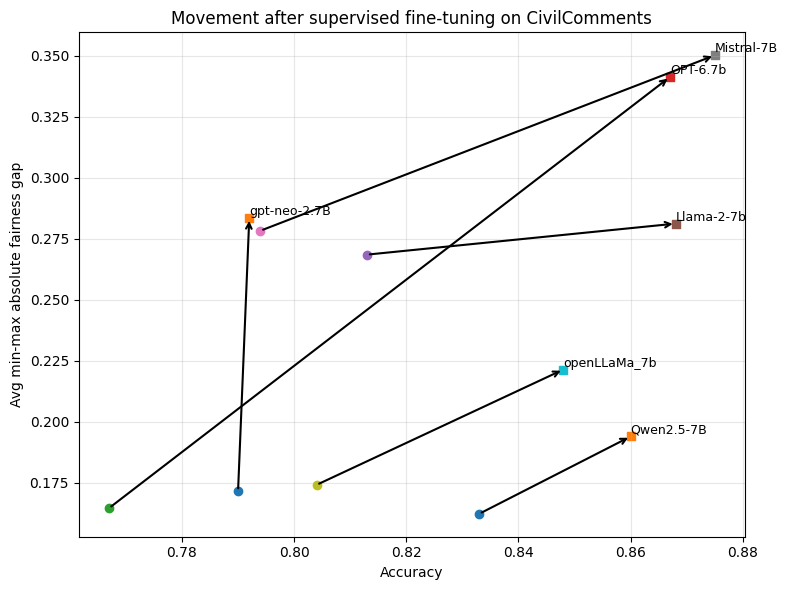

In [15]:
# plot: movement in accuracy-fairness space
# lower fairness gap is better
def plot_before_after_arrows(df):
    plt.figure(figsize=(8, 6))

    for _, row in df.iterrows():
        x0 = row["zero_shot_test_acc"]
        y0 = row["zero_shot_avg_minmax_abs"]
        x1 = row["ft_test_acc"]
        y1 = row["ft_avg_minmax_abs"]

        plt.scatter(x0, y0, marker="o")
        plt.scatter(x1, y1, marker="s")

        plt.annotate(
            "",
            xy=(x1, y1),
            xytext=(x0, y0),
            arrowprops=dict(arrowstyle="->", lw=1.5)
        )

        plt.text(x1, y1, row["short_name"], fontsize=9, ha="left", va="bottom")

    plt.xlabel("Accuracy")
    plt.ylabel("Avg min-max absolute fairness gap")
    plt.title("Movement after supervised fine-tuning on CivilComments")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_before_after_arrows(df_summary)

In [16]:
# before/after table
cols = [
    "year", "short_name",
    "zero_shot_test_acc", "ft_test_acc", "delta_acc",
    "zero_shot_avg_minmax_abs", "ft_avg_minmax_abs", "delta_fairness",
]
df_summary[cols].round(4)

,year,short_name,zero_shot_test_acc,ft_test_acc,delta_acc,zero_shot_avg_minmax_abs,ft_avg_minmax_abs,delta_fairness
0,2021,gpt-neo-2.7B,0.790,0.792,0.002,0.1717,0.2835,0.1119
1,2022,OPT-6.7b,0.767,0.867,0.100,0.1647,0.3413,0.1766
2,2023,Llama-2-7b,0.813,0.868,0.055,0.2686,0.2812,0.0127
3,2023,Mistral-7B,0.794,0.875,0.081,0.2784,0.3502,0.0719
4,2023,openLLaMa_7b,0.804,0.848,0.044,0.1742,0.2215,0.0472
5,2024,Qwen2.5-7B,0.833,0.860,0.027,0.1624,0.1941,0.0317
